In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files
uploaded = files.upload()

Saving traffic_accidents.csv to traffic_accidents.csv


In [5]:
data = pd.read_csv('traffic_accidents.csv')
df = data.copy()
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [7]:
df.isnull().sum()

,0
crash_date,0
traffic_control_device,0
weather_condition,0
lighting_condition,0
first_crash_type,0
trafficway_type,0
alignment,0
roadway_surface_cond,0
road_defect,0
crash_type,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_units,209306.0,2.063300,0.396012,1.0,2.0,2.0,2.0,11.0
injuries_total,209306.0,0.382717,0.799720,0.0,0.0,0.0,1.0,21.0
injuries_fatal,209306.0,0.001859,0.047502,0.0,0.0,0.0,0.0,3.0
injuries_incapacitating,209306.0,0.038102,0.233964,0.0,0.0,0.0,0.0,7.0
injuries_non_incapacitating,209306.0,0.221241,0.614960,0.0,0.0,0.0,0.0,21.0
injuries_reported_not_evident,209306.0,0.121516,0.450865,0.0,0.0,0.0,0.0,15.0
injuries_no_indication,209306.0,2.244002,1.241175,0.0,2.0,2.0,3.0,49.0
crash_hour,209306.0,13.373047,5.603830,0.0,9.0,14.0,17.0,23.0
crash_day_of_week,209306.0,4.144024,1.966864,1.0,2.0,4.0,6.0,7.0
crash_month,209306.0,6.771822,3.427593,1.0,4.0,7.0,10.0,12.0


In [9]:
# sns.set(style="whitegrid", palette="muted")

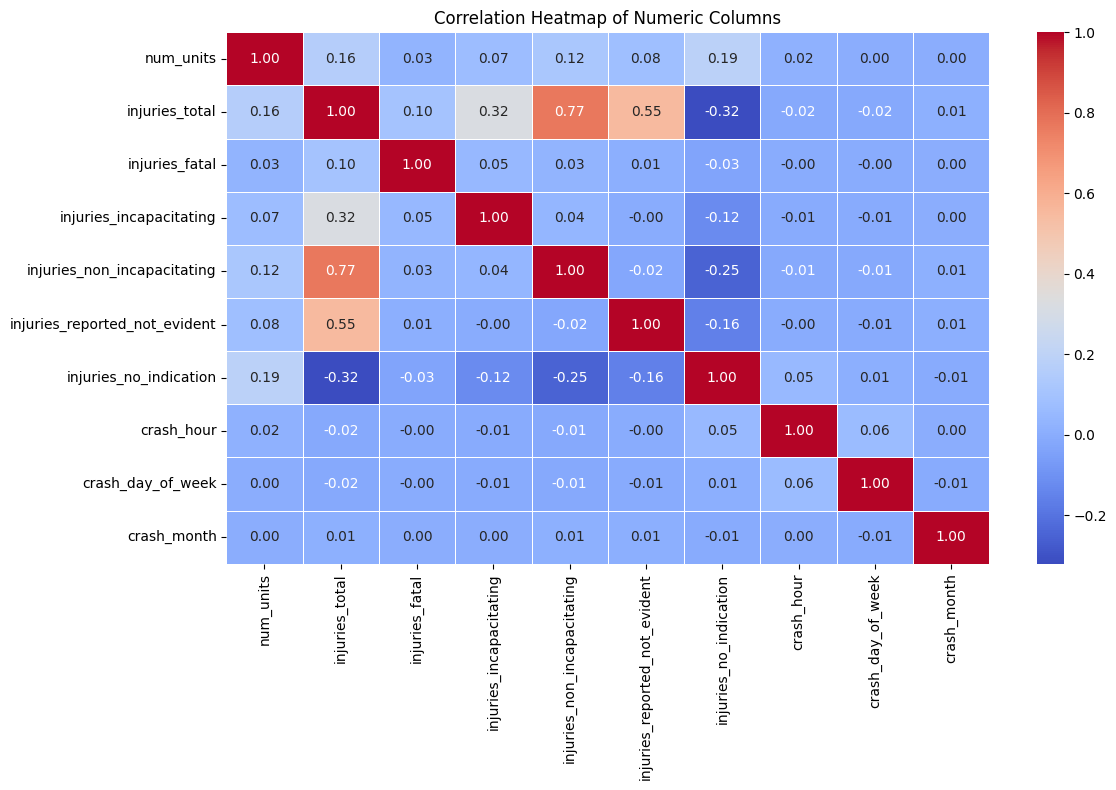

In [10]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Columns')
plt.tight_layout()
plt.show()

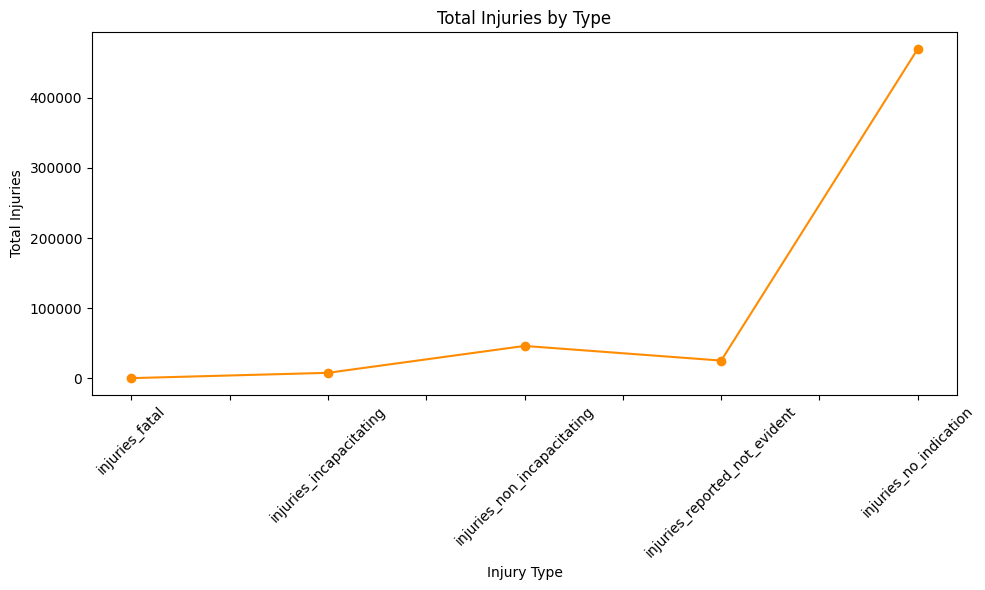

In [11]:

injury_types = ['injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating',
                'injuries_reported_not_evident', 'injuries_no_indication']
injury_totals = df[injury_types].sum()


plt.figure(figsize=(10,6))
injury_totals.plot(kind='line', marker='o', color='darkorange')
plt.title('Total Injuries by Type')
plt.xlabel('Injury Type')
plt.ylabel('Total Injuries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

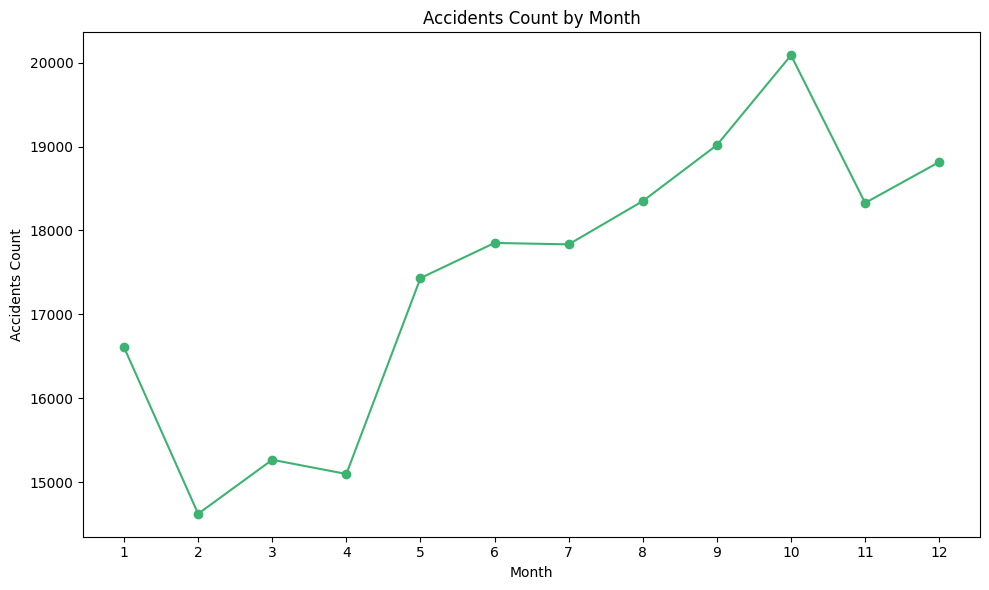

In [12]:
accidents_by_month = df['crash_month'].value_counts().sort_index()

plt.figure(figsize=(10,6))
accidents_by_month.plot(kind='line', marker='o', color='mediumseagreen')
plt.title('Accidents Count by Month')
plt.xlabel('Month')
plt.ylabel('Accidents Count')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

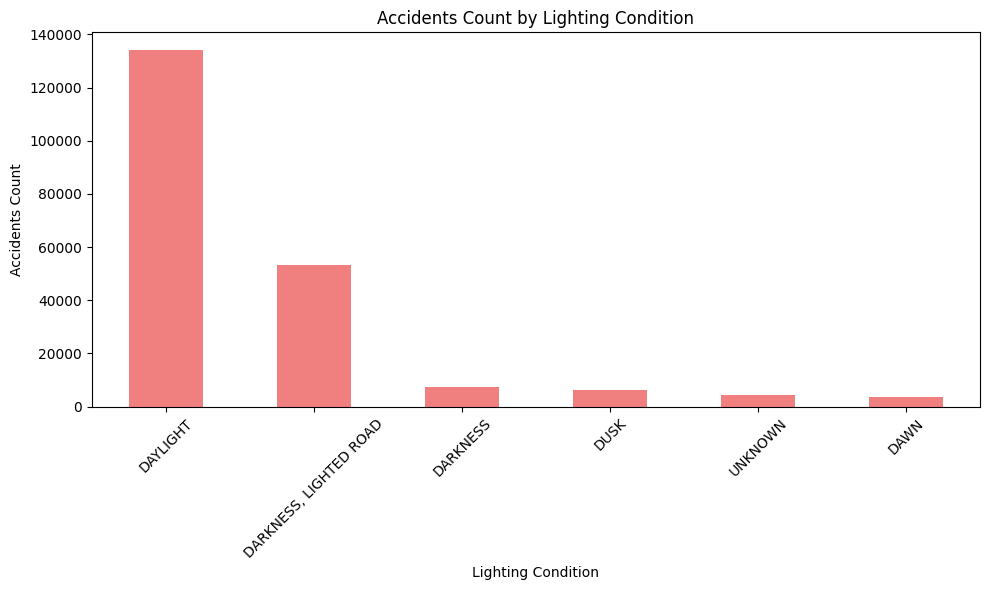

In [13]:
accidents_by_light = df['lighting_condition'].value_counts()

plt.figure(figsize=(10,6))
accidents_by_light.plot(kind='bar', color='lightcoral')
plt.title('Accidents Count by Lighting Condition')
plt.xlabel('Lighting Condition')
plt.ylabel('Accidents Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

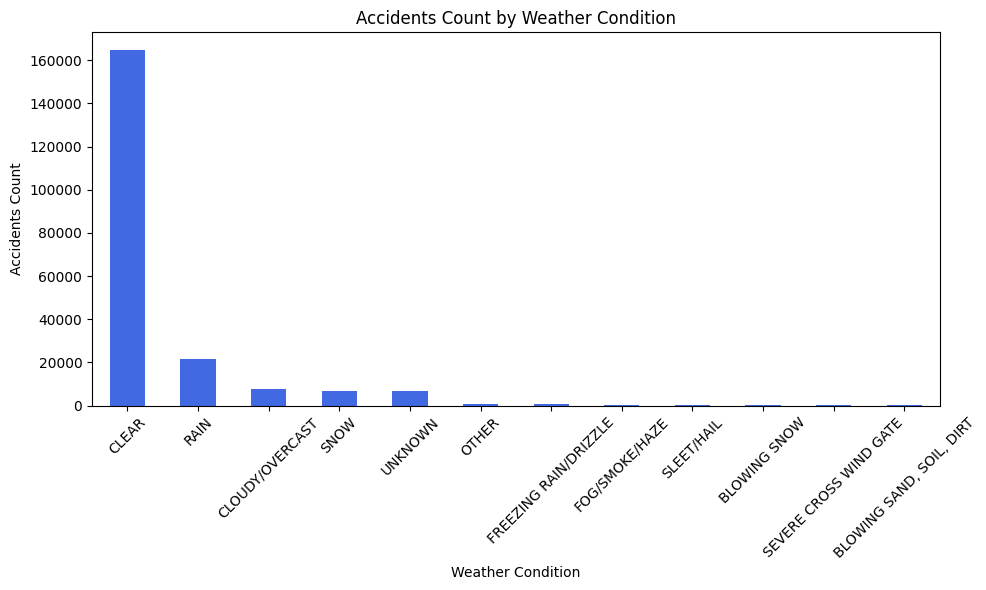

In [14]:

accidents_by_weather = df['weather_condition'].value_counts()


plt.figure(figsize=(10,6))
accidents_by_weather.plot(kind='bar', color='royalblue')
plt.title('Accidents Count by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Accidents Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


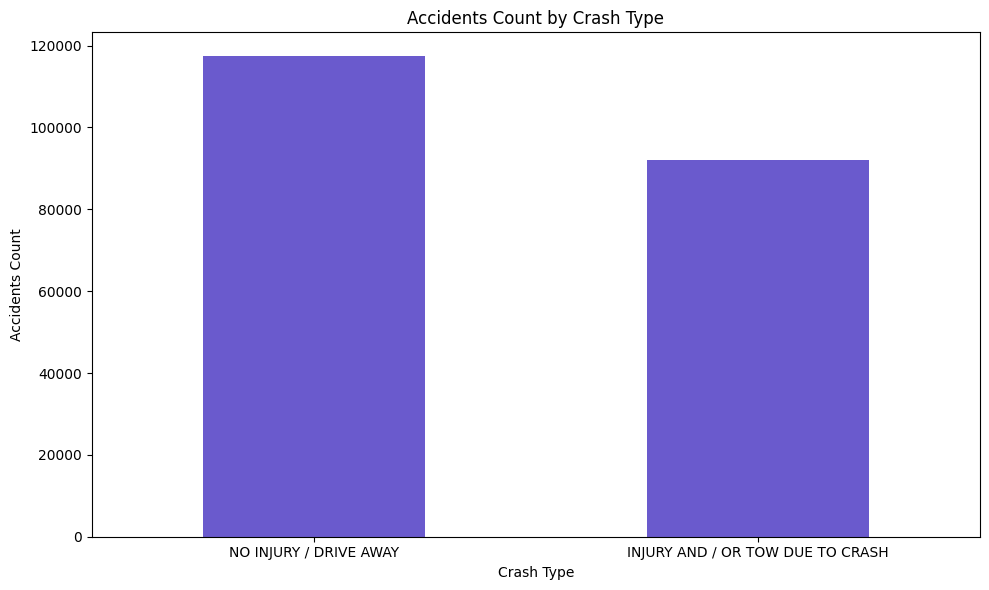

In [15]:
accidents_by_type = df['crash_type'].value_counts()

plt.figure(figsize=(10,6))
accidents_by_type.plot(kind='bar', color='slateblue')
plt.title('Accidents Count by Crash Type')
plt.xlabel('Crash Type')
plt.ylabel('Accidents Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


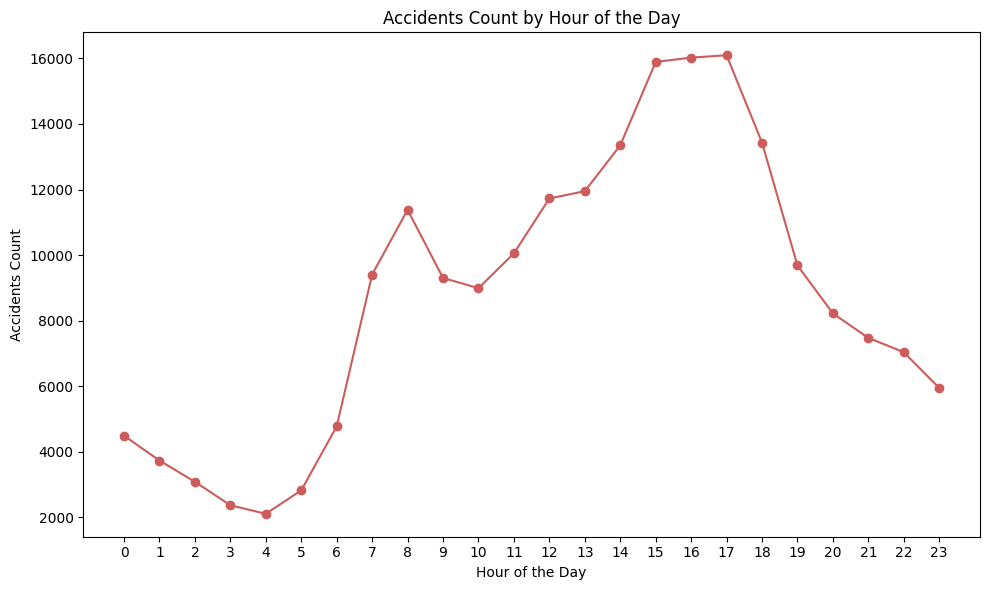

In [16]:
accidents_by_hour = df['crash_hour'].value_counts().sort_index()

plt.figure(figsize=(10,6))
accidents_by_hour.plot(kind='line', marker='o', color='indianred')
plt.title('Accidents Count by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Accidents Count')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

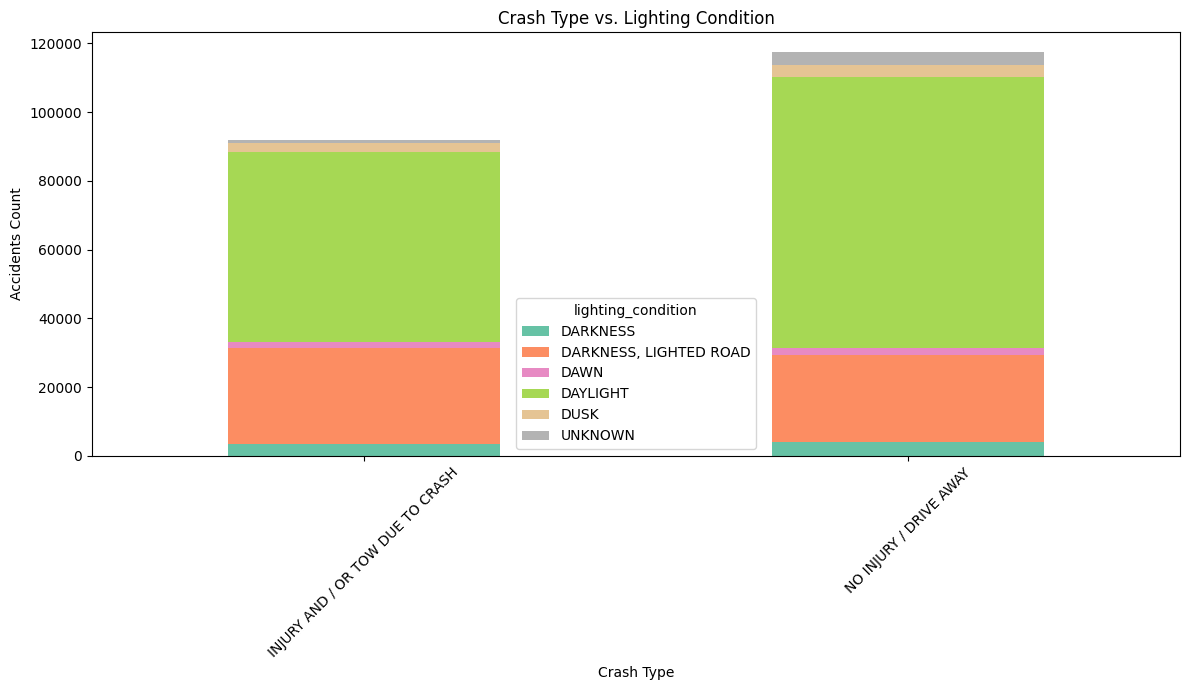

In [17]:
accidents_by_crash_and_light = pd.crosstab(df['crash_type'], df['lighting_condition'])

accidents_by_crash_and_light.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='Set2')
plt.title('Crash Type vs. Lighting Condition')
plt.xlabel('Crash Type')
plt.ylabel('Accidents Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


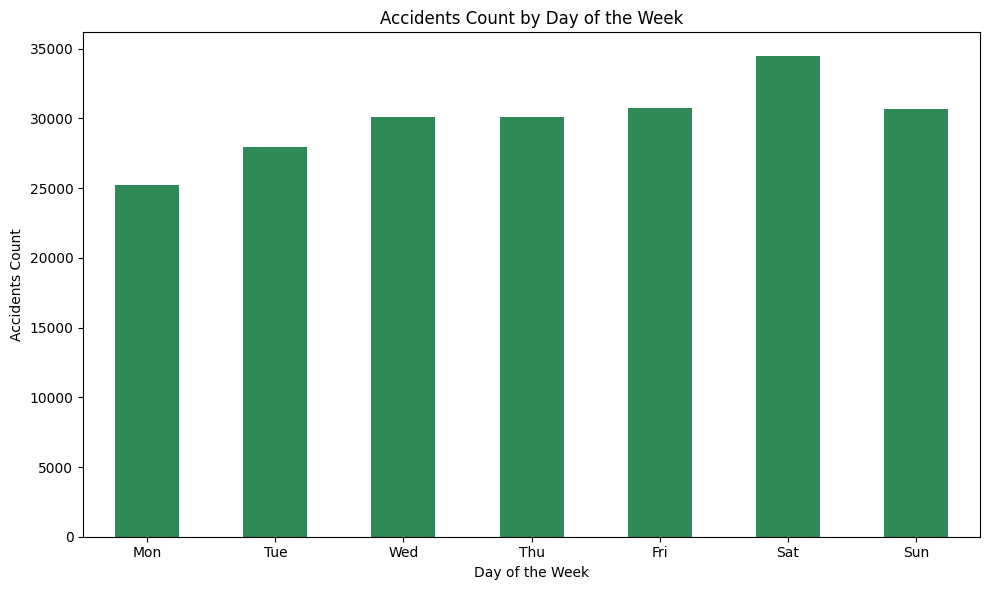

In [18]:
accidents_by_day = df['crash_day_of_week'].value_counts().sort_index()

plt.figure(figsize=(10,6))
accidents_by_day.plot(kind='bar', color='seagreen')
plt.title('Accidents Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Accidents Count')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],rotation=0)
plt.tight_layout()
plt.show()

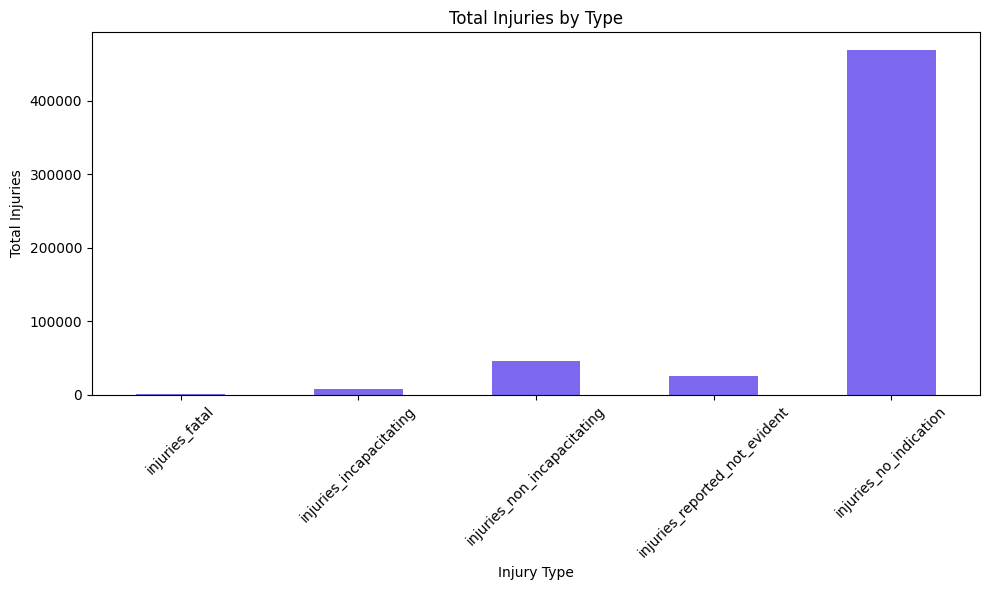

In [19]:
injuries_by_type = df[injury_types].sum()

plt.figure(figsize=(10,6))
injuries_by_type.plot(kind='bar', color='mediumslateblue')
plt.title('Total Injuries by Type')
plt.xlabel('Injury Type')
plt.ylabel('Total Injuries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


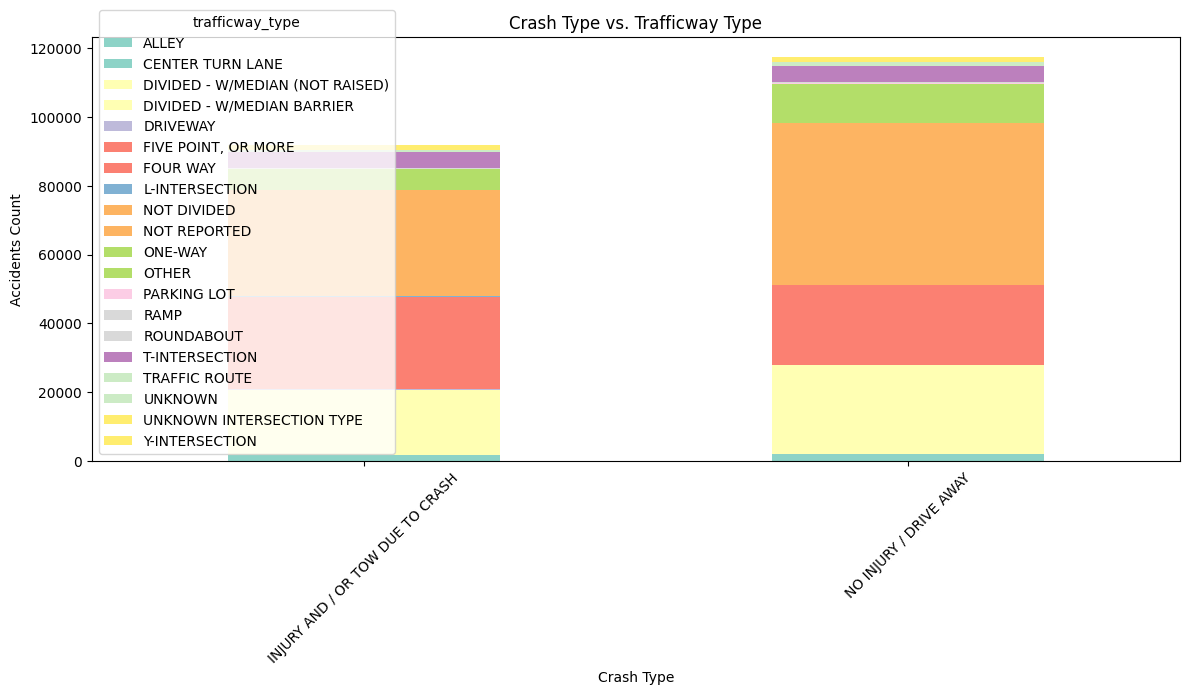

In [20]:
accidents_by_crash_and_road = pd.crosstab(df['crash_type'], df['trafficway_type'])

accidents_by_crash_and_road.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='Set3')
plt.title('Crash Type vs. Trafficway Type')
plt.xlabel('Crash Type')
plt.ylabel('Accidents Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

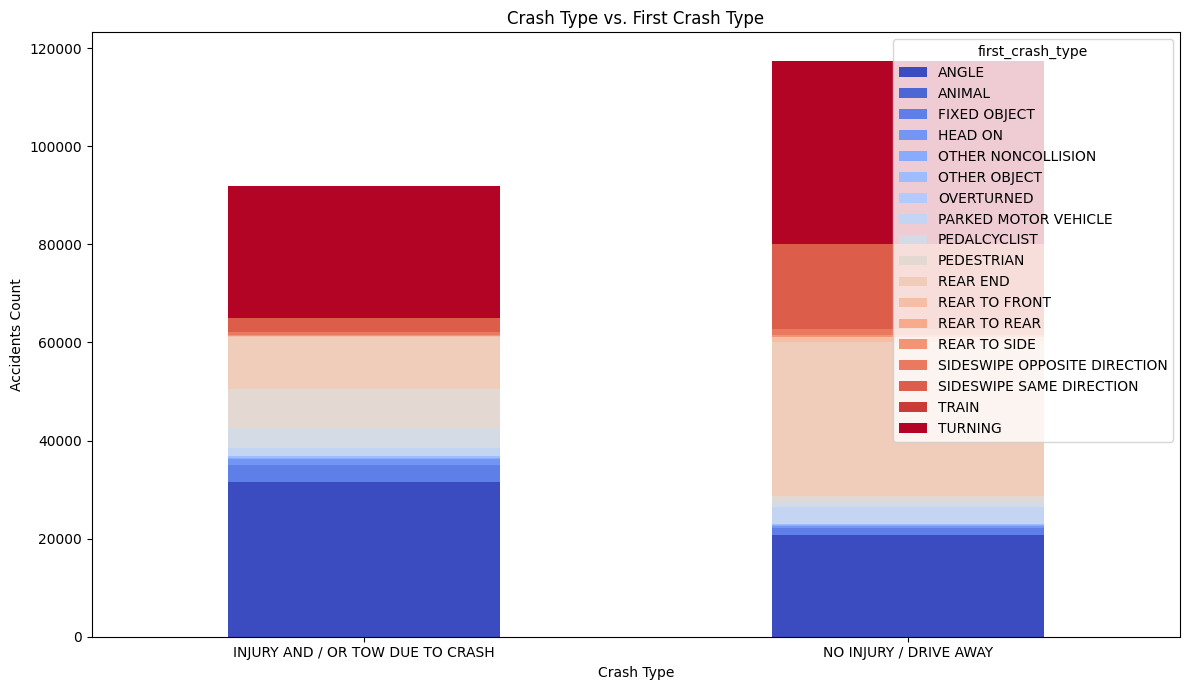

In [21]:
accidents_by_crash_and_first_type = pd.crosstab(df['crash_type'], df['first_crash_type'])

accidents_by_crash_and_first_type.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='coolwarm')
plt.title('Crash Type vs. First Crash Type')
plt.xlabel('Crash Type')
plt.ylabel('Accidents Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

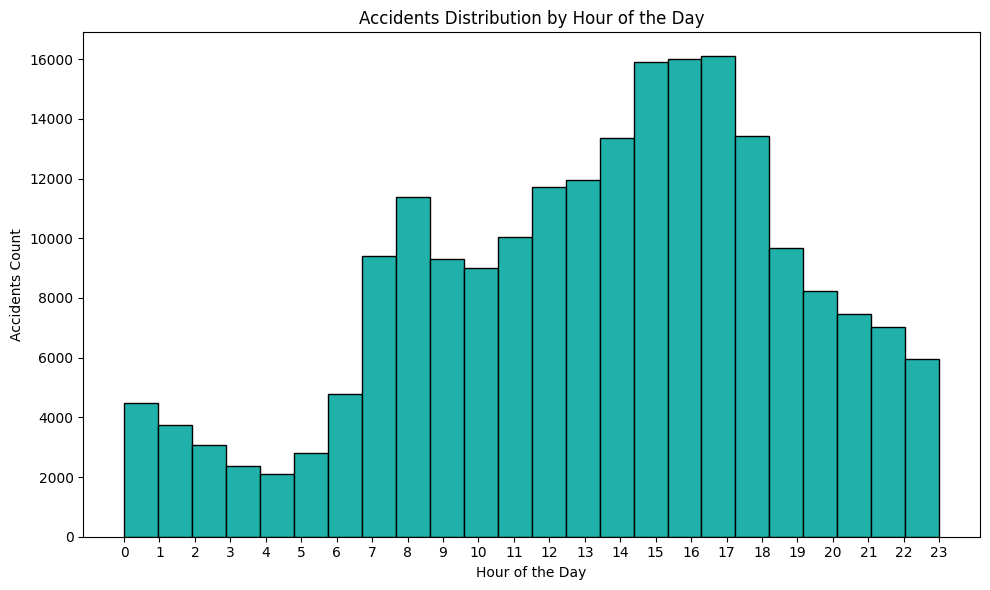

In [22]:
plt.figure(figsize=(10,6))
plt.hist(df['crash_hour'], bins=24, color='lightseagreen', edgecolor='black')
plt.title('Accidents Distribution by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Accidents Count')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

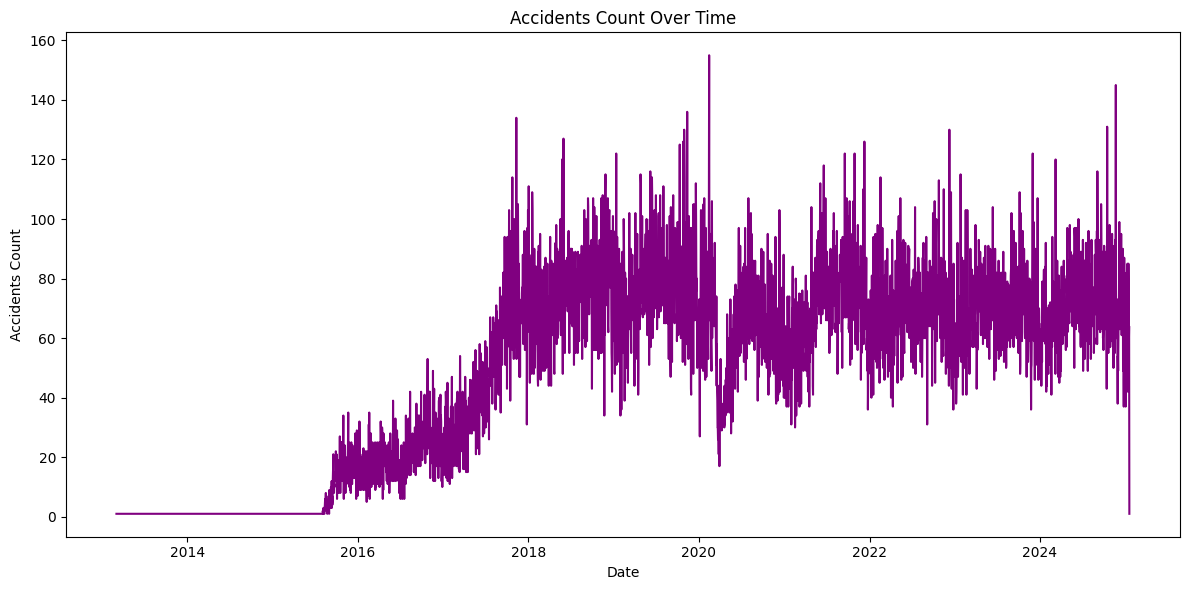

In [23]:
df['crash_date'] = pd.to_datetime(df['crash_date'])

accidents_by_date = df.groupby(df['crash_date'].dt.date).size()

plt.figure(figsize=(12,6))
accidents_by_date.plot(kind='line', color='purple')
plt.title('Accidents Count Over Time')
plt.xlabel('Date')
plt.ylabel('Accidents Count')
plt.tight_layout()
plt.show()

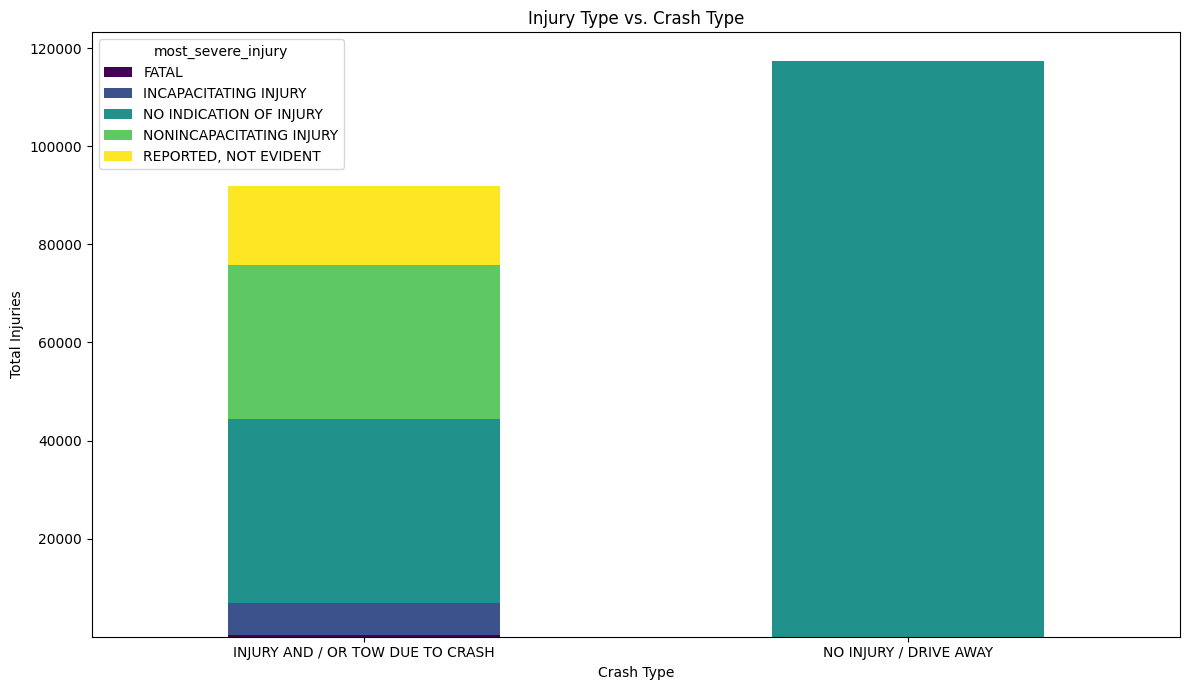

In [24]:
injury_by_crash_type = pd.crosstab(df['crash_type'], df['most_severe_injury'])

injury_by_crash_type.plot(kind='bar', stacked=True, figsize=(12,7), cmap='viridis')
plt.title('Injury Type vs. Crash Type')
plt.xlabel('Crash Type')
plt.ylabel('Total Injuries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
label_encoders = {}

categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:

    original_values = df[column].unique()

    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

    encoded_values = df[column].unique()

    decoded_values = label_encoders[column].inverse_transform(encoded_values)

    print(f"\n{column} Encoding and Decoding:")
    for enc, dec in zip(encoded_values, decoded_values):
        print(f"{enc} -> {dec}")


traffic_control_device Encoding and Decoding:
16 -> TRAFFIC SIGNAL
4 -> NO CONTROLS
15 -> STOP SIGN/FLASHER
17 -> UNKNOWN
6 -> OTHER
10 -> PEDESTRIAN CROSSING SIGN
9 -> OTHER WARNING SIGN
18 -> YIELD
2 -> FLASHING CONTROL SIGNAL
3 -> LANE USE MARKING
8 -> OTHER REG. SIGN
1 -> DELINEATORS
14 -> SCHOOL ZONE
11 -> POLICE/FLAGMAN
5 -> NO PASSING
13 -> RR CROSSING SIGN
12 -> RAILROAD CROSSING GATE
0 -> BICYCLE CROSSING SIGN
7 -> OTHER RAILROAD CROSSING

weather_condition Encoding and Decoding:
2 -> CLEAR
7 -> RAIN
10 -> SNOW
3 -> CLOUDY/OVERCAST
11 -> UNKNOWN
4 -> FOG/SMOKE/HAZE
1 -> BLOWING SNOW
5 -> FREEZING RAIN/DRIZZLE
6 -> OTHER
9 -> SLEET/HAIL
8 -> SEVERE CROSS WIND GATE
0 -> BLOWING SAND, SOIL, DIRT

lighting_condition Encoding and Decoding:
3 -> DAYLIGHT
1 -> DARKNESS, LIGHTED ROAD
4 -> DUSK
0 -> DARKNESS
5 -> UNKNOWN
2 -> DAWN

first_crash_type Encoding and Decoding:
17 -> TURNING
10 -> REAR END
0 -> ANGLE
2 -> FIXED OBJECT
11 -> REAR TO FRONT
15 -> SIDESWIPE SAME DIRECTION
14 -> 

In [26]:
df = df.drop(columns=['crash_date'])

In [27]:
X = df.drop(columns=['crash_type'])
y = df['crash_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scikit-learn RandomForestClassifier model removed as per user request.

In [ ]:
# Scikit-learn LogisticRegression model removed as per user request.

In [ ]:
# Scikit-learn DecisionTreeClassifier model removed as per user request.

In [ ]:
# Scikit-learn KNeighborsClassifier model removed as per user request.

In [ ]:
# Scikit-learn model comparison removed as per user request.

## Implementing Models with Keras

Now, let's implement a simple neural network using Keras (built on TensorFlow) for the classification task. This will replace the scikit-learn based models.

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Ensure the data is in the correct format for Keras (numpy arrays)
X_train_keras = X_train.to_numpy()
X_test_keras = X_test.to_numpy()
y_train_keras = y_train.to_numpy()
y_test_keras = y_test.to_numpy()

In [29]:
# Define the Keras model
keras_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_keras.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
keras_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train and Evaluate the Keras Model

In [30]:
# Train the model
history = keras_model.fit(X_train_keras, y_train_keras, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, keras_test_accuracy = keras_model.evaluate(X_test_keras, y_test_keras, verbose=0)
print(f"\nKeras Model Test Accuracy: {keras_test_accuracy:.4f}")

# Make predictions
y_pred_keras_prob = keras_model.predict(X_test_keras)
y_pred_keras = (y_pred_keras_prob > 0.5).astype(int)

print("\nKeras Classification Report:")
print(classification_report(y_test_keras, y_pred_keras))
print("\nKeras Confusion Matrix:")
print(confusion_matrix(y_test_keras, y_pred_keras))

Epoch 1/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7887 - loss: 0.4402 - val_accuracy: 0.8298 - val_loss: 0.3520
Epoch 2/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8283 - loss: 0.3540 - val_accuracy: 0.8323 - val_loss: 0.3399
Epoch 3/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8304 - loss: 0.3463 - val_accuracy: 0.8346 - val_loss: 0.3404
Epoch 4/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8314 - loss: 0.3442 - val_accuracy: 0.8331 - val_loss: 0.3388
Epoch 5/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8315 - loss: 0.3426 - val_accuracy: 0.8345 - val_loss: 0.3378
Epoch 6/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8323 - loss: 0.3410 - val_accuracy: 0.8373 - val_loss: 0.3342
Epoch 7/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8312 - loss: 0.3419 - val_accuracy: 0.8347 - val_loss: 0.3398
Epoch 8/10
4187/4187 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8326 - loss: 0

## Saving Model and Encoders for Streamlit App

To use the trained Keras model and the `LabelEncoder`s in a Streamlit application, we need to save them to disk. We'll use `model.save()` for the Keras model and `joblib` for the dictionary of `LabelEncoder` objects.

In [31]:
# Save the Keras model
keras_model.save('keras_model.h5')
print("Keras model saved as 'keras_model.h5'")

# Save the label_encoders dictionary
import joblib
joblib.dump(label_encoders, 'label_encoders.joblib')
print("Label encoders saved as 'label_encoders.joblib'")

# Save the list of feature columns for the Streamlit app to use
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.joblib')
print("Feature columns saved as 'feature_columns.joblib'")

Keras model saved as 'keras_model.h5'
Label encoders saved as 'label_encoders.joblib'
Feature columns saved as 'feature_columns.joblib'


## Install Streamlit and Joblib

We need to install `streamlit` to run the web application and `joblib` to load our saved encoders and feature columns.

In [32]:
!pip install streamlit joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 78.9 MB/s eta 0:00:00


## Create Streamlit Application File (`app.py`)

Now, let's create the `app.py` file which will contain our Streamlit application logic. This app will allow you to:

1.  **Upload a CSV file**: The app will preprocess the data, make predictions using the Keras model, and display the classification report and confusion matrix.
2.  **Manually input features**: You can enter values for each feature, and the app will predict the crash type for that single instance.

In [33]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load the trained Keras model
@st.cache_resource
def load_keras_model():
    model = keras.models.load_model('keras_model.h5')
    return model

model = load_keras_model()

# Load the label encoders and feature columns
@st.cache_resource
def load_artifacts():
    label_encoders = joblib.load('label_encoders.joblib')
    feature_columns = joblib.load('feature_columns.joblib')
    return label_encoders, feature_columns

label_encoders, feature_columns = load_artifacts()

# Title of the Streamlit app
st.title('Traffic Accident Prediction App (Keras)')

st.markdown("""
This application predicts the 'crash_type' (whether it's an 'INJURY AND / OR TOW DUE TO CRASH' or 'NO INJURY / DRIVE AWAY') based on various features.
""")

# --- CSV File Upload Section ---
st.header('1. Upload CSV for Batch Prediction')
uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

if uploaded_file is not None:
    try:
        input_df = pd.read_csv(uploaded_file)
        st.write("Original Data Head:")
        st.write(input_df.head())

        # Drop 'crash_date' if it exists
        if 'crash_date' in input_df.columns:
            input_df = input_df.drop(columns=['crash_date'])

        # Prepare the data for prediction
        processed_df = input_df.copy()
        for col in feature_columns:
            if col in label_encoders and col in processed_df.columns:
                # Handle unseen labels during inverse transform if necessary, for robustness
                # Here we assume the input data will have labels seen during training
                # For unseen labels, you might want to map them to an 'unknown' category or handle specifically
                # For simplicity, we'll try to transform directly. If an error occurs, it means unseen data.
                try:
                    processed_df[col] = label_encoders[col].transform(processed_df[col])
                except ValueError as e:
                    st.warning(f"Warning: Unseen labels in column '{col}'. Skipping encoding for this column in uploaded CSV. Error: {e}")
                    # A more robust solution would be to map unseen labels to a default or treat as a new category
                    pass
            elif col not in processed_df.columns:
                st.warning(f"Warning: Feature column '{col}' not found in uploaded CSV. Prediction might be affected.")

        # Align columns to match training data features used by the model
        # This is crucial if the uploaded CSV has different columns or order
        # For simplicity, we ensure all model features are present, filling missing with 0 or a mean/mode
        # (A more advanced approach would handle this carefully based on feature importance)
        processed_df_aligned = pd.DataFrame(columns=feature_columns)
        for col in feature_columns:
            if col in processed_df.columns:
                processed_df_aligned[col] = processed_df[col]
            else:
                processed_df_aligned[col] = 0 # Or some other sensible default

        # Make predictions
        keras_predictions_prob = model.predict(processed_df_aligned.to_numpy())
        keras_predictions = (keras_predictions_prob > 0.5).astype(int)

        # Add predictions to the input_df for display
        input_df['predicted_crash_type'] = np.where(keras_predictions == 1, 'NO INJURY / DRIVE AWAY', 'INJURY AND / OR TOW DUE TO CRASH')

        st.write("Predicted Data Head (with original values for 'crash_type'):")
        st.write(input_df.head())

        # If the uploaded CSV contains the actual 'crash_type' for evaluation
        if 'crash_type' in input_df.columns:
            # Decode the original 'crash_type' if it was encoded
            original_crash_type_decoded = label_encoders['crash_type'].inverse_transform(input_df['crash_type'])
            st.write("### Evaluation of Predictions on Uploaded Data")
            st.write("Classification Report:")
            st.text(classification_report(original_crash_type_decoded, input_df['predicted_crash_type']))
            st.write("Confusion Matrix:")
            st.text(confusion_matrix(original_crash_type_decoded, input_df['predicted_crash_type']))
        else:
            st.info("To evaluate model performance, please ensure the uploaded CSV contains a 'crash_type' column.")


    except Exception as e:
        st.error(f"Error processing file: {e}")


# --- Manual Input Section ---
st.header('2. Manual Input for Single Accident Condition')

manual_inputs = {}
for col in feature_columns:
    if col in label_encoders:
        options = label_encoders[col].classes_.tolist()
        manual_inputs[col] = st.selectbox(f"Select {col.replace('_', ' ').title()}", options=options)
    else:
        # Assuming numerical columns not in label_encoders are numeric inputs
        # You might need to adjust default values based on your data's range
        if col.startswith('injuries'):
            manual_inputs[col] = st.number_input(f"Enter {col.replace('_', ' ').title()}", min_value=0.0, value=0.0, step=1.0)
        elif col == 'num_units':
            manual_inputs[col] = st.number_input(f"Enter {col.replace('_', ' ').title()}", min_value=1, value=2, step=1)
        elif col == 'crash_hour':
            manual_inputs[col] = st.slider(f"Select {col.replace('_', ' ').title()}", min_value=0, max_value=23, value=12)
        elif col == 'crash_day_of_week':
            manual_inputs[col] = st.slider(f"Select {col.replace('_', ' ').title()}", min_value=1, max_value=7, value=4) # 1=Mon, 7=Sun
        elif col == 'crash_month':
            manual_inputs[col] = st.slider(f"Select {col.replace('_', ' ').title()}", min_value=1, max_value=12, value=7)
        else:
            manual_inputs[col] = st.text_input(f"Enter {col.replace('_', ' ').title()}", value="") # Fallback for unknown types


if st.button('Predict Manual Input'):
    try:
        single_instance_df = pd.DataFrame([manual_inputs])

        # Apply label encoding to manual inputs
        for col in feature_columns:
            if col in label_encoders:
                single_instance_df[col] = label_encoders[col].transform(single_instance_df[col])
            # Numerical columns are already in appropriate format from st.number_input/slider

        # Ensure column order matches training order
        single_instance_df_aligned = single_instance_df[feature_columns]

        # Make prediction
        single_prediction_prob = model.predict(single_instance_df_aligned.to_numpy())
        single_prediction = (single_prediction_prob > 0.5).astype(int)[0][0]

        predicted_label = 'NO INJURY / DRIVE AWAY' if single_prediction == 1 else 'INJURY AND / OR TOW DUE TO CRASH'

        st.success(f"Predicted Crash Type: **{predicted_label}**")
        st.info(f"Prediction Probability (for 'NO INJURY / DRIVE AWAY'): {single_prediction_prob[0][0]:.4f}")

    except Exception as e:
        st.error(f"Error during manual prediction: {e}")

Writing app.py


## Run the Streamlit App

Execute the cell below to start the Streamlit application. It will provide a public URL you can click to access the front-end.

In [34]:
# Install ngrok if not already installed
!pip install pyngrok -q

from pyngrok import ngrok
import os

# Hardcoding ngrok authtoken as requested by the user
NGROK_AUTH_TOKEN = '2nAUp5YnDqOJPFrgKfyCjLiJOiO_6Dmdt6jWfHTruszLzii7D'

# Set authtoken (if not already set)
if not os.path.exists("~/.ngrok2/ngrok.yml"):
  ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Terminate any existing ngrok tunnels
ngrok.kill()

# Start ngrok tunnel for Streamlit on port 8501
# It's important to run Streamlit in the background for ngrok to work properly
print("Starting Streamlit app in background...")
get_ipython().system_raw('streamlit run app.py &')

# Open a ngrok tunnel to the Streamlit port
tunnel = ngrok.connect(8501)
public_url = tunnel.public_url

print(f"Streamlit app running at: {public_url}")
print("You can also check the local URL: http://localhost:8501")

Starting Streamlit app in background...
Streamlit app running at: https://3461-35-245-142-100.ngrok-free.app
You can also check the local URL: http://localhost:8501
